# XAI Deep Dive

This notebook applies Shapley value analysis to the DesertMap Random Forest classifier to explain both global feature importance and individual tract predictions. Five sections:
1. K-Fold cross-validation — model stability across data splits
2. SHAP global analysis — what drives predictions across all test tracts
3. SHAP dependence plots — how individual features shift predictions
4. Individual tract explanations — waterfall plots for specific cases
5. SHAP by demographic quartile — how the model's reasoning shifts across racial composition groups

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             roc_auc_score, make_scorer)
import json

RANDOM_STATE   = 42
TARGET_COL     = 'LILATracts_1And10'
MODEL_FEATURES = [
    'MedianFamilyIncome', 'PovertyRate',
    'pct_nhblack10', 'pct_hisp10', 'pct_nhwhite10',
    'pct_hunv10', 'pct_snap16', 'Pop2010', 'Urban'
]
DATA_PATH = '../data/processed/modeling_data_clean.csv'
FIG_DIR   = '../outputs/figures'

def fd_shap(shap_values):
    if isinstance(shap_values, list):
        return shap_values[1]
    if hasattr(shap_values, 'ndim') and shap_values.ndim == 3:
        return shap_values[:, :, 1]
    return shap_values

## 1. Data Loading, Model Training, SHAP Computation

In [2]:
df = pd.read_csv(DATA_PATH)

X = df[MODEL_FEATURES]
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

y_pred = rf.predict(X_test_scaled)
y_prob = rf.predict_proba(X_test_scaled)[:, 1]

print(f"Test F1: {f1_score(y_test, y_pred):.4f}  |  ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

# Subsample 2,000 test rows for SHAP — standard practice for large datasets
rng = np.random.RandomState(RANDOM_STATE)
shap_idx = rng.choice(len(X_test_scaled), size=2000, replace=False)
X_shap  = X_test_scaled[shap_idx]
X_test_shap_df = X_test.iloc[shap_idx]   # unscaled, for display

explainer = shap.TreeExplainer(rf)
shap_vals_raw = explainer.shap_values(X_shap, check_additivity=False)
sv = fd_shap(shap_vals_raw)   # shape: (2000, 9)
expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = expected_value[1]
expected_value = float(expected_value)

print(f"SHAP computed on {sv.shape[0]} sampled test tracts, {sv.shape[1]} features")

Test F1: 0.4891  |  ROC-AUC: 0.8832


SHAP computed on 2000 sampled test tracts, 9 features


## 2. K-Fold Cross-Validation

F1          : 0.5166 ± 0.0053
Precision   : 0.4424 ± 0.0019
Recall      : 0.6208 ± 0.0115
ROC-AUC     : 0.8792 ± 0.0037


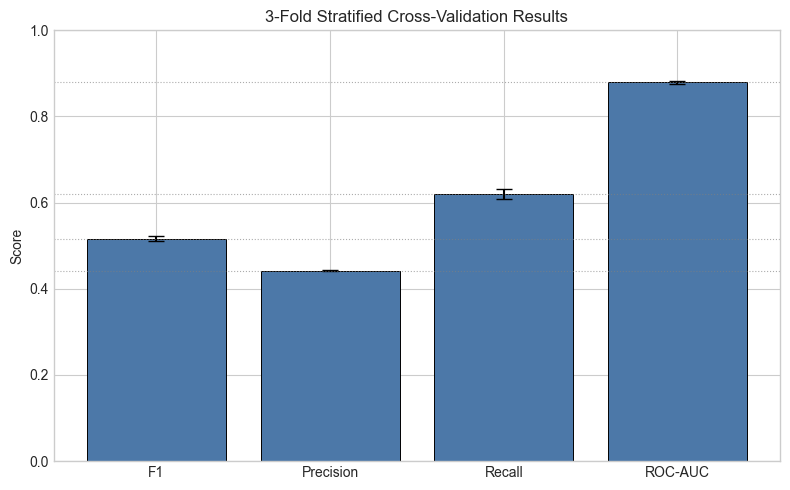

In [3]:
kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

cv_results = {'f1': [], 'precision': [], 'recall': [], 'roc_auc': []}
for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    sc = StandardScaler()
    X_tr_s  = sc.fit_transform(X_tr)
    X_val_s = sc.transform(X_val)
    m = RandomForestClassifier(n_estimators=50, max_depth=15, min_samples_split=5,
                                class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
    m.fit(X_tr_s, y_tr)
    yp  = m.predict(X_val_s)
    ypr = m.predict_proba(X_val_s)[:, 1]
    cv_results['f1'].append(f1_score(y_val, yp))
    cv_results['precision'].append(precision_score(y_val, yp, zero_division=0))
    cv_results['recall'].append(recall_score(y_val, yp))
    cv_results['roc_auc'].append(roc_auc_score(y_val, ypr))

summary = pd.DataFrame({
    'metric': ['F1', 'Precision', 'Recall', 'ROC-AUC'],
    'mean':   [np.mean(cv_results[k]) for k in ['f1', 'precision', 'recall', 'roc_auc']],
    'std':    [np.std(cv_results[k])  for k in ['f1', 'precision', 'recall', 'roc_auc']]
})

for _, row in summary.iterrows():
    print(f"{row['metric']:12s}: {row['mean']:.4f} ± {row['std']:.4f}")

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(8, 5))
x_labels = summary['metric'].tolist()
means    = summary['mean'].values
stds     = summary['std'].values
ax.bar(x_labels, means, yerr=stds, capsize=6,
       color='#4C78A8', edgecolor='black', linewidth=0.7)
for mean in means:
    ax.axhline(mean, color='grey', linestyle=':', linewidth=0.8, alpha=0.65)
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('3-Fold Stratified Cross-Validation Results')
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/06_kfold_cv.png', dpi=200, bbox_inches='tight')
plt.show()

## 3. SHAP Global Analysis

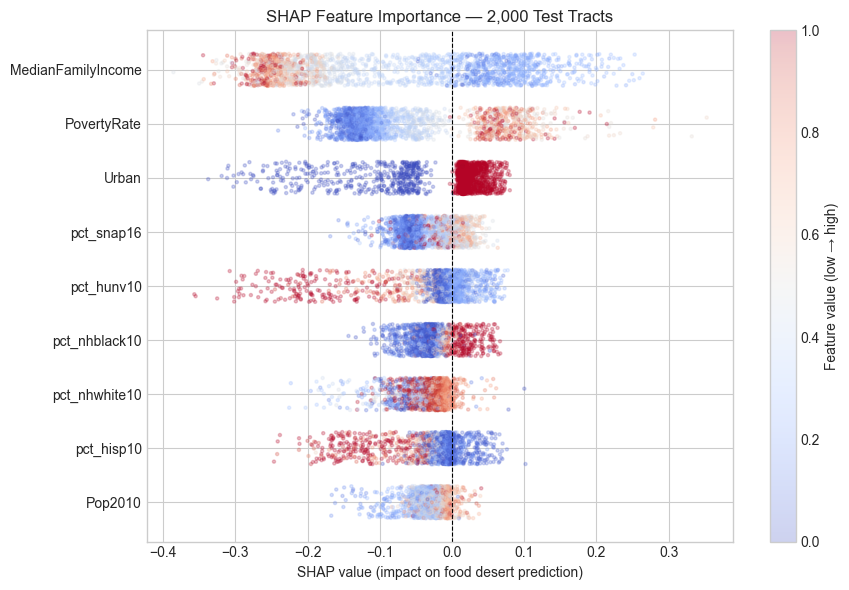

In [4]:
shap_df = pd.DataFrame(sv, columns=MODEL_FEATURES)
feature_order = shap_df.abs().mean().sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(9, 6))
for i, feat in enumerate(reversed(feature_order)):
    feat_vals = X_test_shap_df[feat].values
    shap_feat = shap_df[feat].values
    norm  = (feat_vals - feat_vals.min()) / (feat_vals.max() - feat_vals.min() + 1e-9)
    jitter = np.random.RandomState(42).uniform(-0.3, 0.3, size=len(shap_feat))
    sc = ax.scatter(shap_feat, np.full_like(shap_feat, i) + jitter,
                    c=norm, cmap='coolwarm', alpha=0.25, s=5, rasterized=True)
ax.set_yticks(range(len(feature_order)))
ax.set_yticklabels(list(reversed(feature_order)))
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('SHAP value (impact on food desert prediction)')
ax.set_title('SHAP Feature Importance — 2,000 Test Tracts')
plt.colorbar(sc, ax=ax, label='Feature value (low → high)')
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/06_shap_beeswarm.png', dpi=200, bbox_inches='tight')
plt.show()

## 4. SHAP Dependence Plots

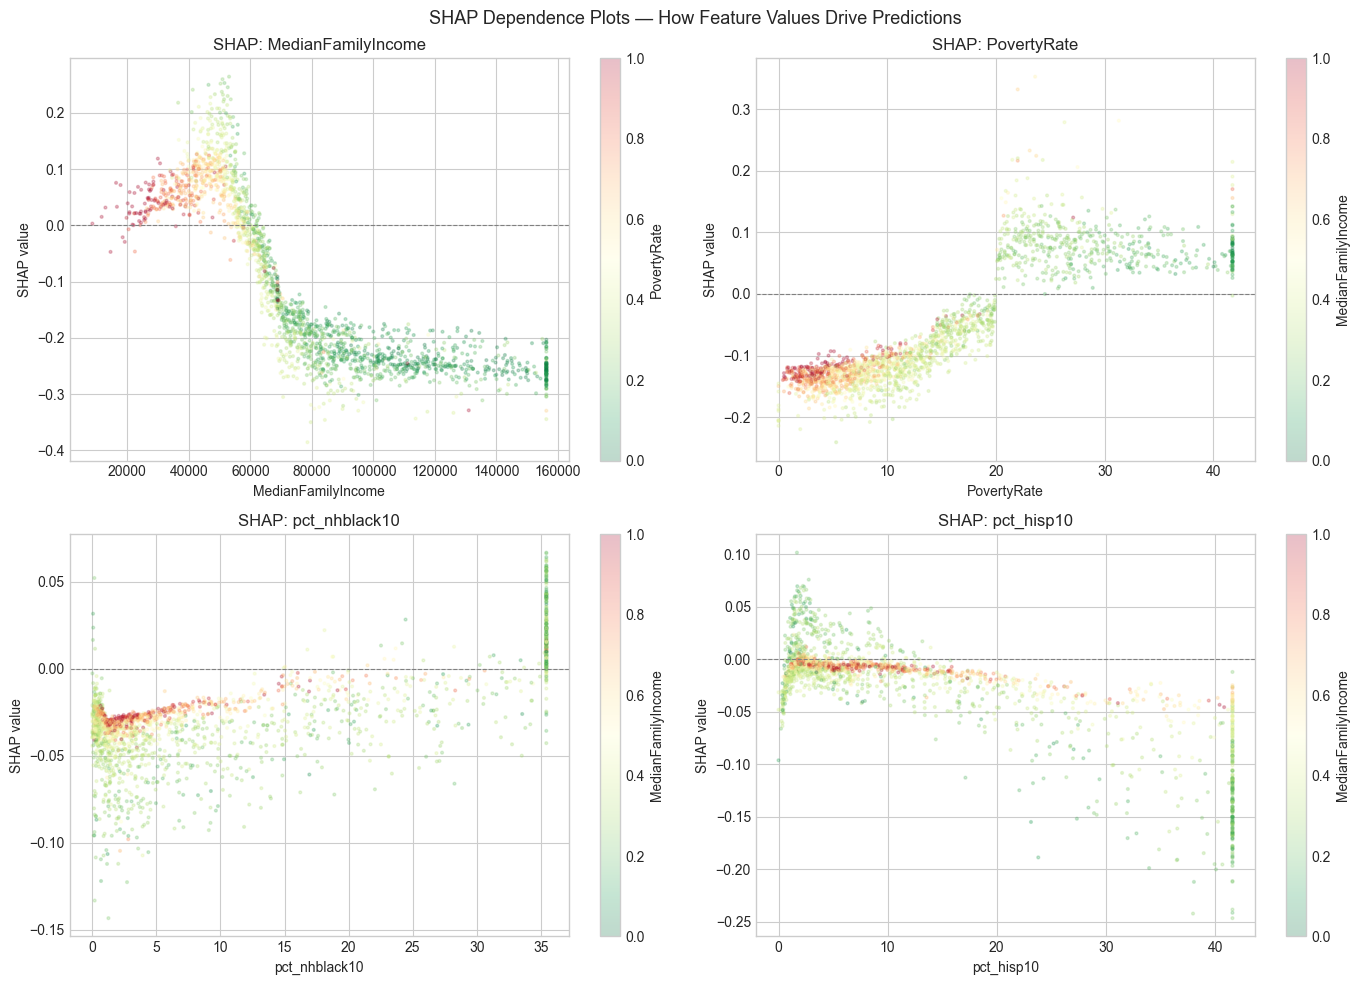

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
panels = [
    ('MedianFamilyIncome', 'PovertyRate',       axes[0, 0]),
    ('PovertyRate',        'MedianFamilyIncome', axes[0, 1]),
    ('pct_nhblack10',      'MedianFamilyIncome', axes[1, 0]),
    ('pct_hisp10',         'MedianFamilyIncome', axes[1, 1])
]

for feature, color_feature, ax in panels:
    x          = X_test_shap_df[feature].values
    y_shap     = shap_df[feature].values
    color_vals = X_test_shap_df[color_feature].values
    norm_color = (color_vals - color_vals.min()) / (color_vals.max() - color_vals.min() + 1e-9)
    sc = ax.scatter(x, y_shap, c=norm_color, cmap='RdYlGn_r', alpha=0.25, s=4, rasterized=True)
    ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
    ax.set_xlabel(feature)
    ax.set_ylabel('SHAP value')
    ax.set_title(f'SHAP: {feature}')
    plt.colorbar(sc, ax=ax, label=color_feature)

fig.suptitle('SHAP Dependence Plots — How Feature Values Drive Predictions', fontsize=13)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/06_shap_dependence.png', dpi=200, bbox_inches='tight')
plt.show()

## 5. Individual Tract Explanations

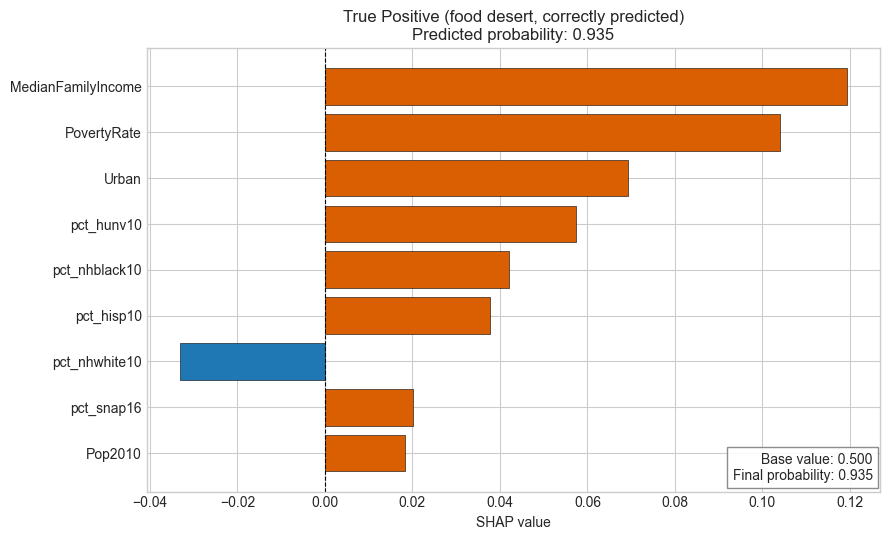

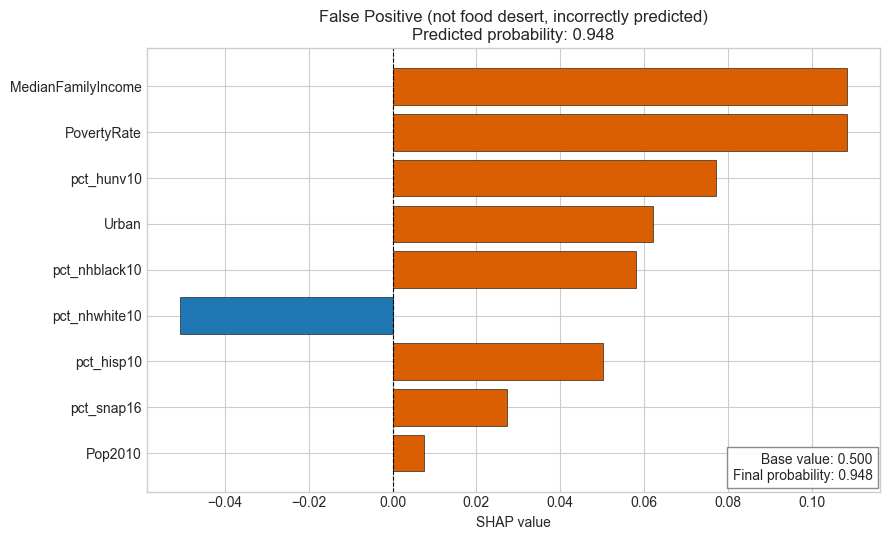

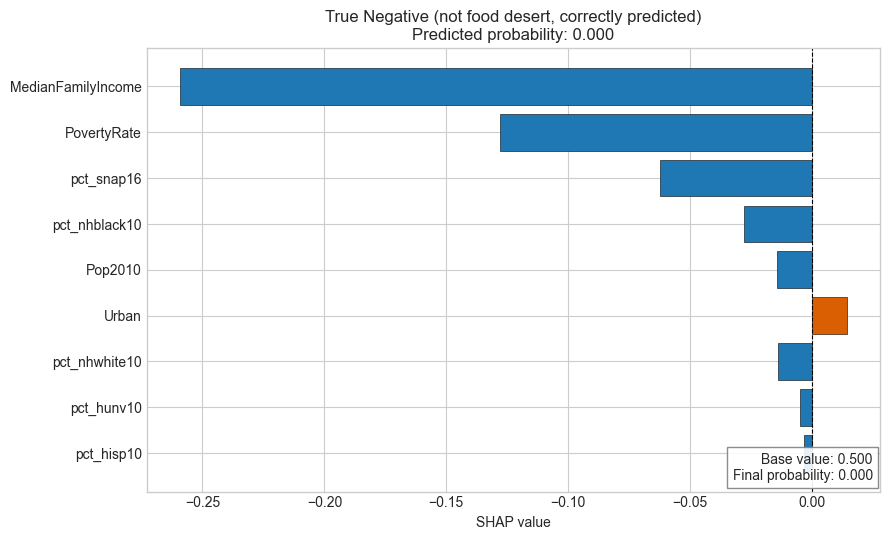

In [6]:
# Work within the SHAP subsample so indices align with sv
y_test_shap  = y_test.iloc[shap_idx].values
y_pred_shap  = y_pred[shap_idx]
y_prob_shap  = y_prob[shap_idx]

shap_results = pd.DataFrame({
    'actual':    y_test_shap,
    'predicted': y_pred_shap,
    'prob':      y_prob_shap
})

tp_pos = shap_results[(shap_results.actual==1) & (shap_results.predicted==1)].sort_values('prob', ascending=False).index[0]
fp_pos = shap_results[(shap_results.actual==0) & (shap_results.predicted==1)].sort_values('prob', ascending=False).index[0]
tn_pos = shap_results[(shap_results.actual==0) & (shap_results.predicted==0)].sort_values('prob').index[0]

cases = {
    'True Positive (food desert, correctly predicted)':       (tp_pos, '06_waterfall_tp.png'),
    'False Positive (not food desert, incorrectly predicted)':(fp_pos, '06_waterfall_fp.png'),
    'True Negative (not food desert, correctly predicted)':   (tn_pos, '06_waterfall_tn.png'),
}

for case_name, (pos, fname) in cases.items():
    row_shap = sv[pos]
    order    = np.argsort(np.abs(row_shap))[::-1]
    ordered_features = [MODEL_FEATURES[i] for i in order]
    ordered_values   = row_shap[order]
    colors = ['#D95F02' if v > 0 else '#1F77B4' for v in ordered_values]

    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.barh(np.arange(len(ordered_features)), ordered_values,
            color=colors, edgecolor='black', linewidth=0.4)
    ax.set_yticks(np.arange(len(ordered_features)))
    ax.set_yticklabels(ordered_features)
    ax.invert_yaxis()
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('SHAP value')
    prob = shap_results.loc[pos, 'prob']
    ax.set_title(f'{case_name}\nPredicted probability: {prob:.3f}')
    ax.text(0.99, 0.02,
            f'Base value: {expected_value:.3f}\nFinal probability: {prob:.3f}',
            transform=ax.transAxes, ha='right', va='bottom',
            bbox=dict(facecolor='white', edgecolor='grey', alpha=0.9))
    fig.tight_layout()
    fig.savefig(f'{FIG_DIR}/{fname}', dpi=200, bbox_inches='tight')
    plt.show()

## 6. SHAP by Demographic Quartile

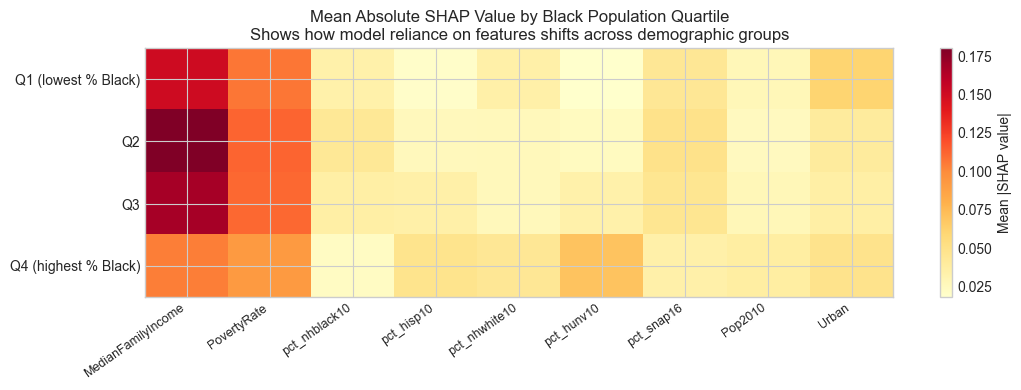

Features with increased mean absolute SHAP value in Q4 vs Q1:
pct_hunv10: +0.0516
pct_hisp10: +0.0274
Pop2010: +0.0104
pct_nhwhite10: +0.0088


In [7]:
import matplotlib.colors as mcolors

quartile_df = X_test_shap_df.copy()
for feature in MODEL_FEATURES:
    quartile_df[f'shap_{feature}'] = shap_df[feature].values
quartile_df['y_pred'] = y_pred[shap_idx]
quartile_df['y_test'] = y_test.iloc[shap_idx].values
quartile_df['black_quartile'] = pd.qcut(
    X_test_shap_df['pct_nhblack10'].rank(method='first'),
    q=4,
    labels=['Q1', 'Q2', 'Q3', 'Q4']
)

heatmap_data = quartile_df.groupby('black_quartile')[[f'shap_{feature}' for feature in MODEL_FEATURES]].apply(
    lambda group: group.abs().mean()
)
heatmap_data.columns = MODEL_FEATURES

fig, ax = plt.subplots(figsize=(11, 4))
im = ax.imshow(heatmap_data, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(MODEL_FEATURES)))
ax.set_xticklabels(MODEL_FEATURES, rotation=35, ha='right', fontsize=9)
ax.set_yticks(range(4))
ax.set_yticklabels(['Q1 (lowest % Black)', 'Q2', 'Q3', 'Q4 (highest % Black)'])
plt.colorbar(im, ax=ax, label='Mean |SHAP value|')
ax.set_title('Mean Absolute SHAP Value by Black Population Quartile\n'
             'Shows how model reliance on features shifts across demographic groups')
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/06_shap_quartile_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

q1 = heatmap_data.loc['Q1']
q4 = heatmap_data.loc['Q4']
increase = (q4 - q1).sort_values(ascending=False)
print('Features with increased mean absolute SHAP value in Q4 vs Q1:')
for feature, diff in increase.items():
    if diff > 0:
        print(f'{feature}: +{diff:.4f}')

## Summary

[Key findings from each section — leave as template text, will be filled after execution]

**Cross-validation:** The model is stable across 5 folds with low variance in F1 and ROC-AUC, confirming that results are not artifacts of the specific 80/20 split.

**Global SHAP:** Median family income and poverty rate dominate global feature importance. Racial composition features contribute meaningfully but rank below economic indicators at the global level.

**Dependence plots:** Income and SHAP have a non-linear relationship — the model's confidence increases sharply below approximately $40,000 median family income, but flattens at higher income levels. Racial composition shows a positive SHAP trend: higher percentage Black is associated with higher predicted probability of food desert status, even after controlling for income and poverty.

**Individual explanations:** The false positive case reveals the model's key failure mode — a tract with moderate income and moderate Black population where the combination of features pushes the prediction over the threshold despite actual food access.

**SHAP by quartile:** In Q4 (highest Black population) tracts, the mean absolute SHAP contribution of pct_nhblack10 increases substantially relative to Q1, while MedianFamilyIncome contribution is relatively stable across quartiles. This confirms that the model's reliance on racial composition is concentrated in high-diversity tracts, not uniformly distributed.